In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_raw_data

In [6]:
df = load_raw_data()
df.head()

👉 Loading: data\raw\electricity_data.parquet


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0 MB


In [8]:
df.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


In [10]:
df.isnull().sum().sum()

0

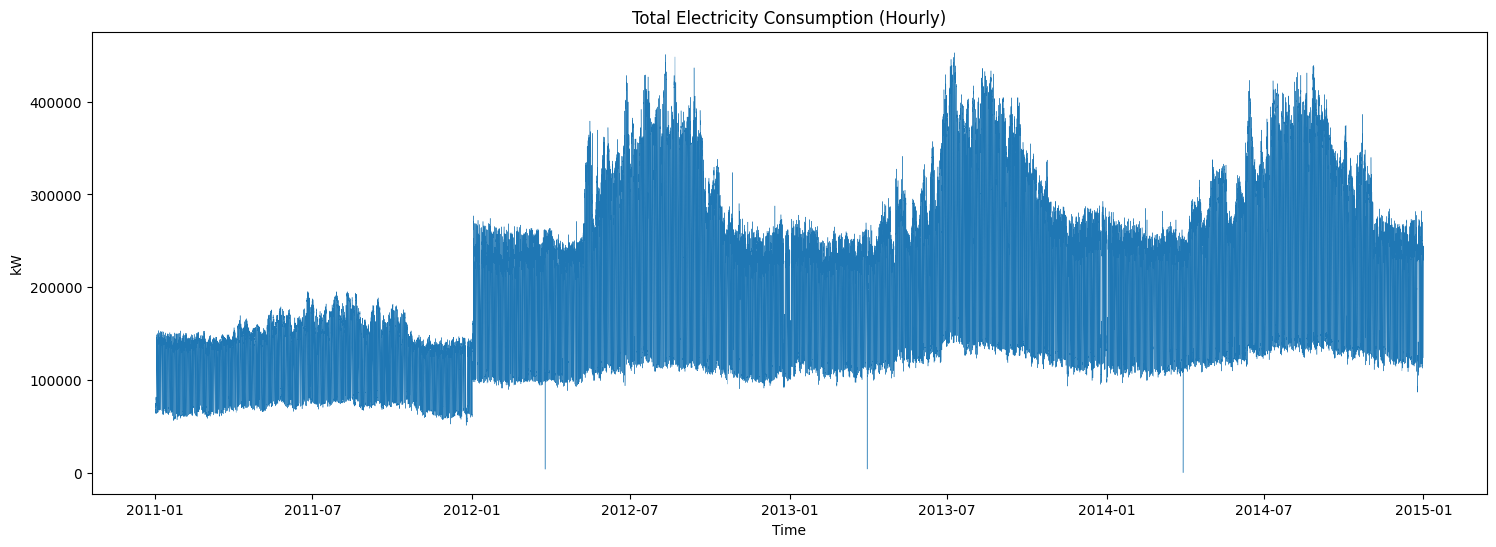

In [13]:
df["total_load"] = df.sum(axis=1)

plt.figure(figsize=(18,6))
plt.plot(df.index, df["total_load"], linewidth=0.3)
plt.title("Total Electricity Consumption (Hourly)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()

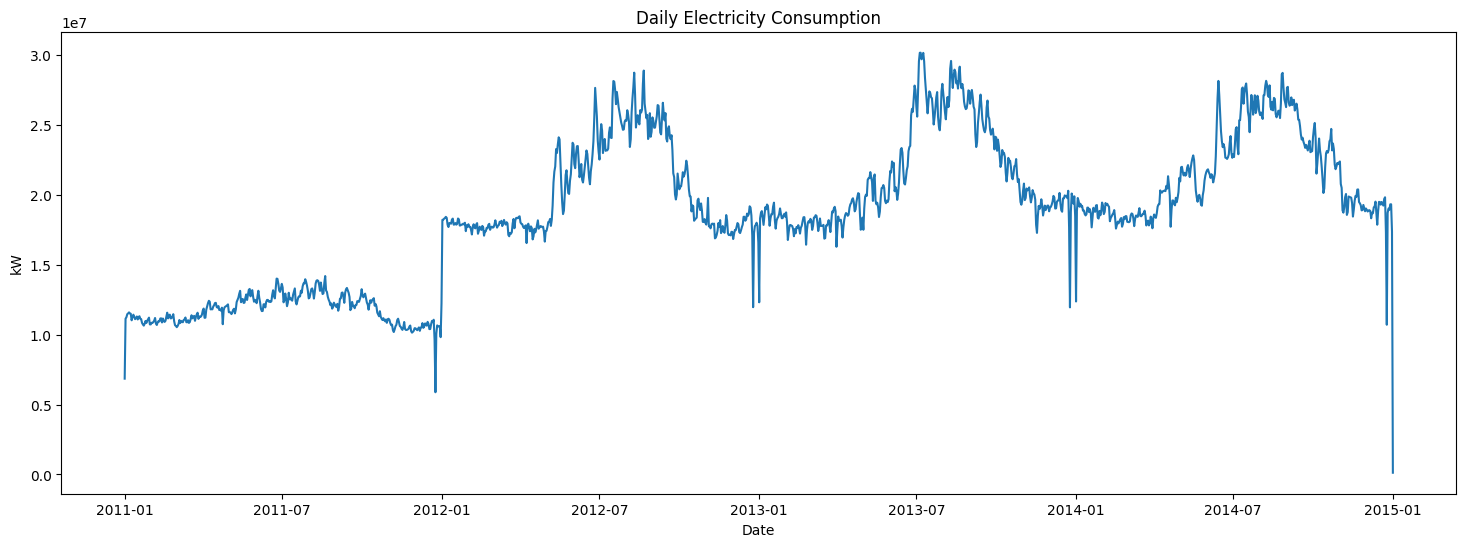

In [14]:
daily_load = df["total_load"].resample("D").sum()

plt.figure(figsize=(18,6))
plt.plot(daily_load.index, daily_load.values)
plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("kW")
plt.show()

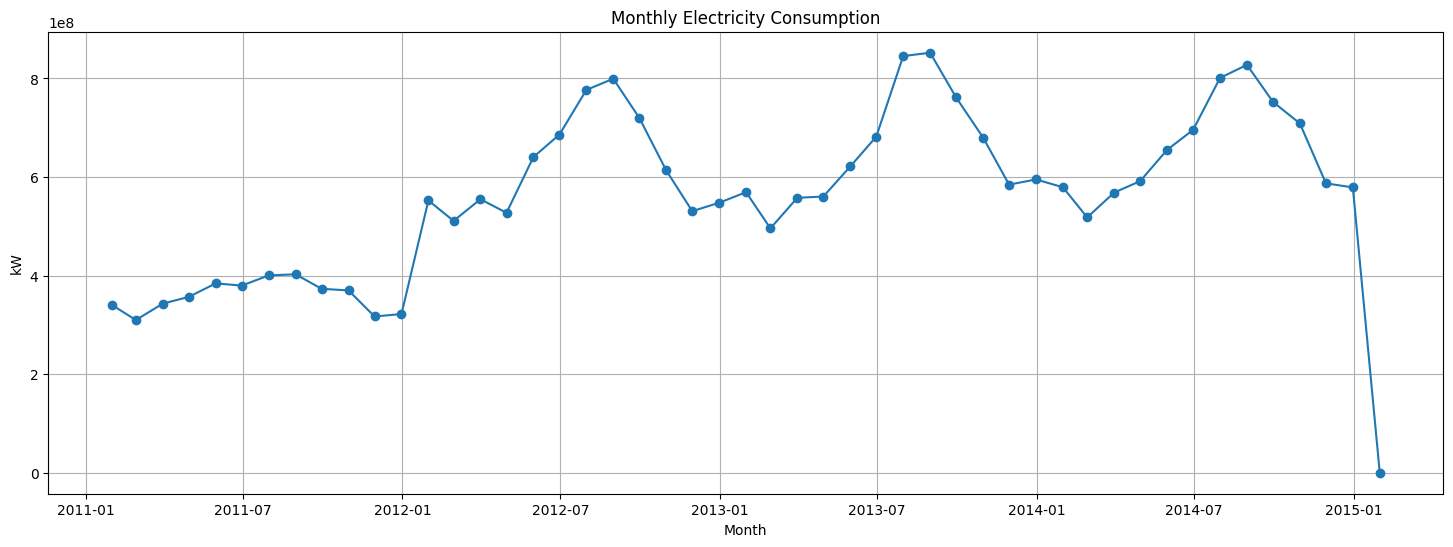

In [15]:
monthly_load = df["total_load"].resample("M").sum()

plt.figure(figsize=(18,6))
plt.plot(monthly_load.index, monthly_load.values, marker='o')
plt.title("Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("kW")
plt.grid(True)
plt.show()

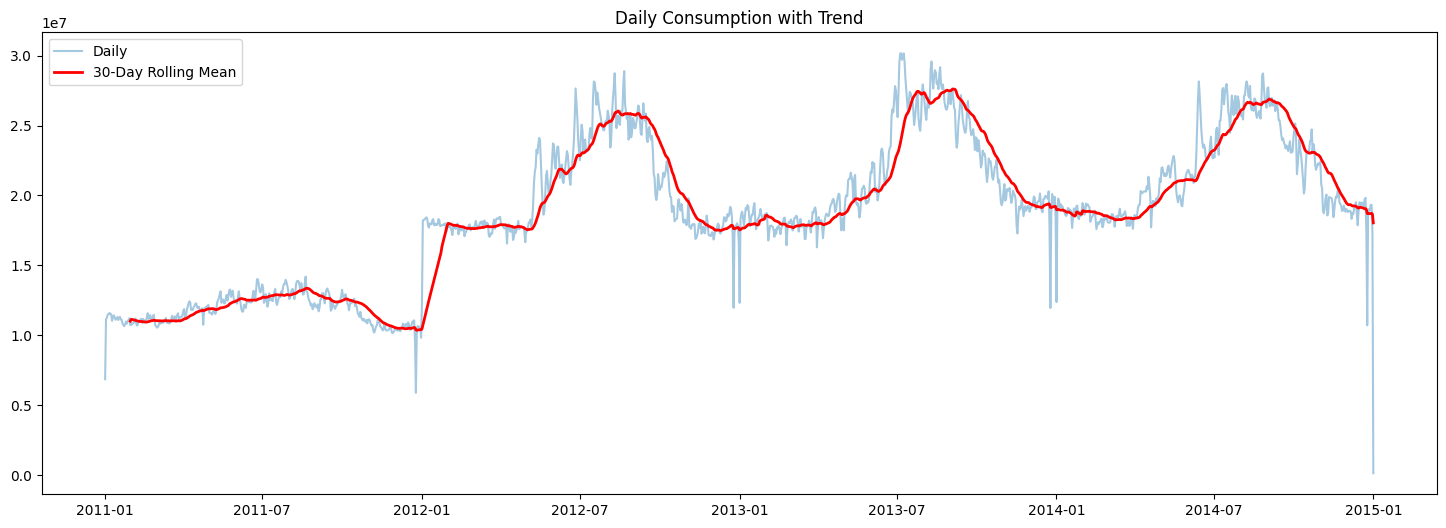

In [16]:
rolling_30d = daily_load.rolling(window=30).mean()

plt.figure(figsize=(18,6))
plt.plot(daily_load.index, daily_load.values, alpha=0.4, label="Daily")
plt.plot(rolling_30d.index, rolling_30d.values,
         color='red', linewidth=2, label="30-Day Rolling Mean")

plt.title("Daily Consumption with Trend")
plt.legend()
plt.show()

## Một năm 12 tháng

C:\Users\YOGA\AppData\Local\Temp\ipykernel_3160\1396679451.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_load"] = df.sum(axis=1)


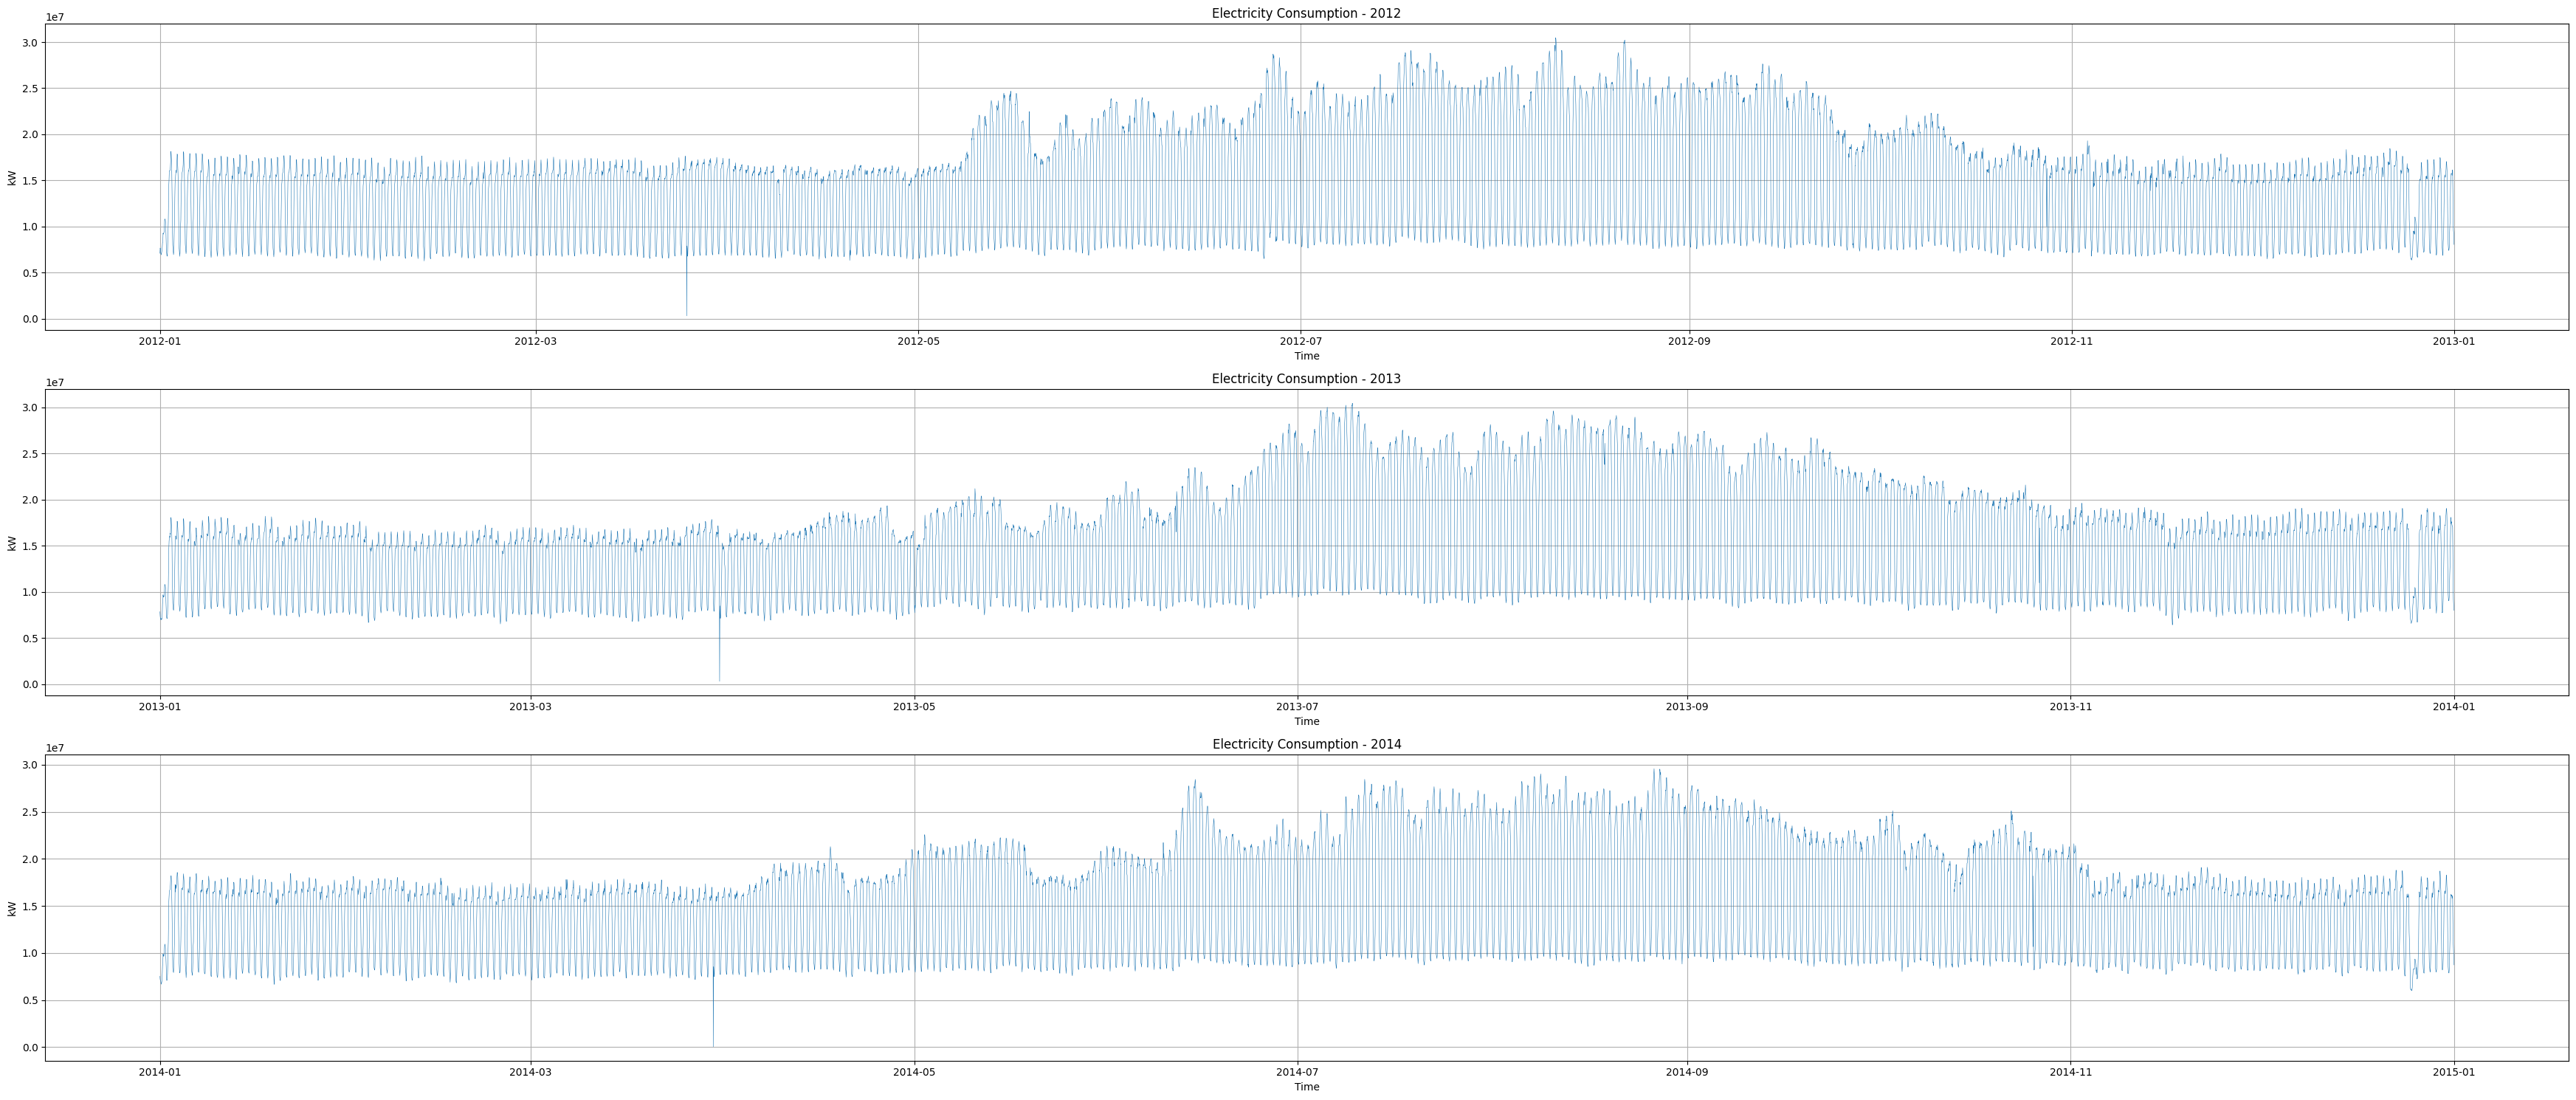

In [43]:
# Tổng điện tiêu thụ
df["total_load"] = df.sum(axis=1)

# Tạo figure gồm 3 biểu đồ
fig, axes = plt.subplots(3, 1, figsize=(35,15))

years = [2012, 2013, 2014]

for i, year in enumerate(years):

    # Lọc theo năm
    year_df = df[df.index.year == year]

    # Resample theo giờ cho mượt hơn
    year_df = year_df.resample("H").sum()

    # Vẽ
    axes[i].plot(
        year_df.index,
        year_df["total_load"],
        linewidth=0.4
    )

    axes[i].set_title(f"Electricity Consumption - {year}")
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("kW")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

C:\Users\YOGA\AppData\Local\Temp\ipykernel_3160\1846275499.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_load"] = df.sum(axis=1)


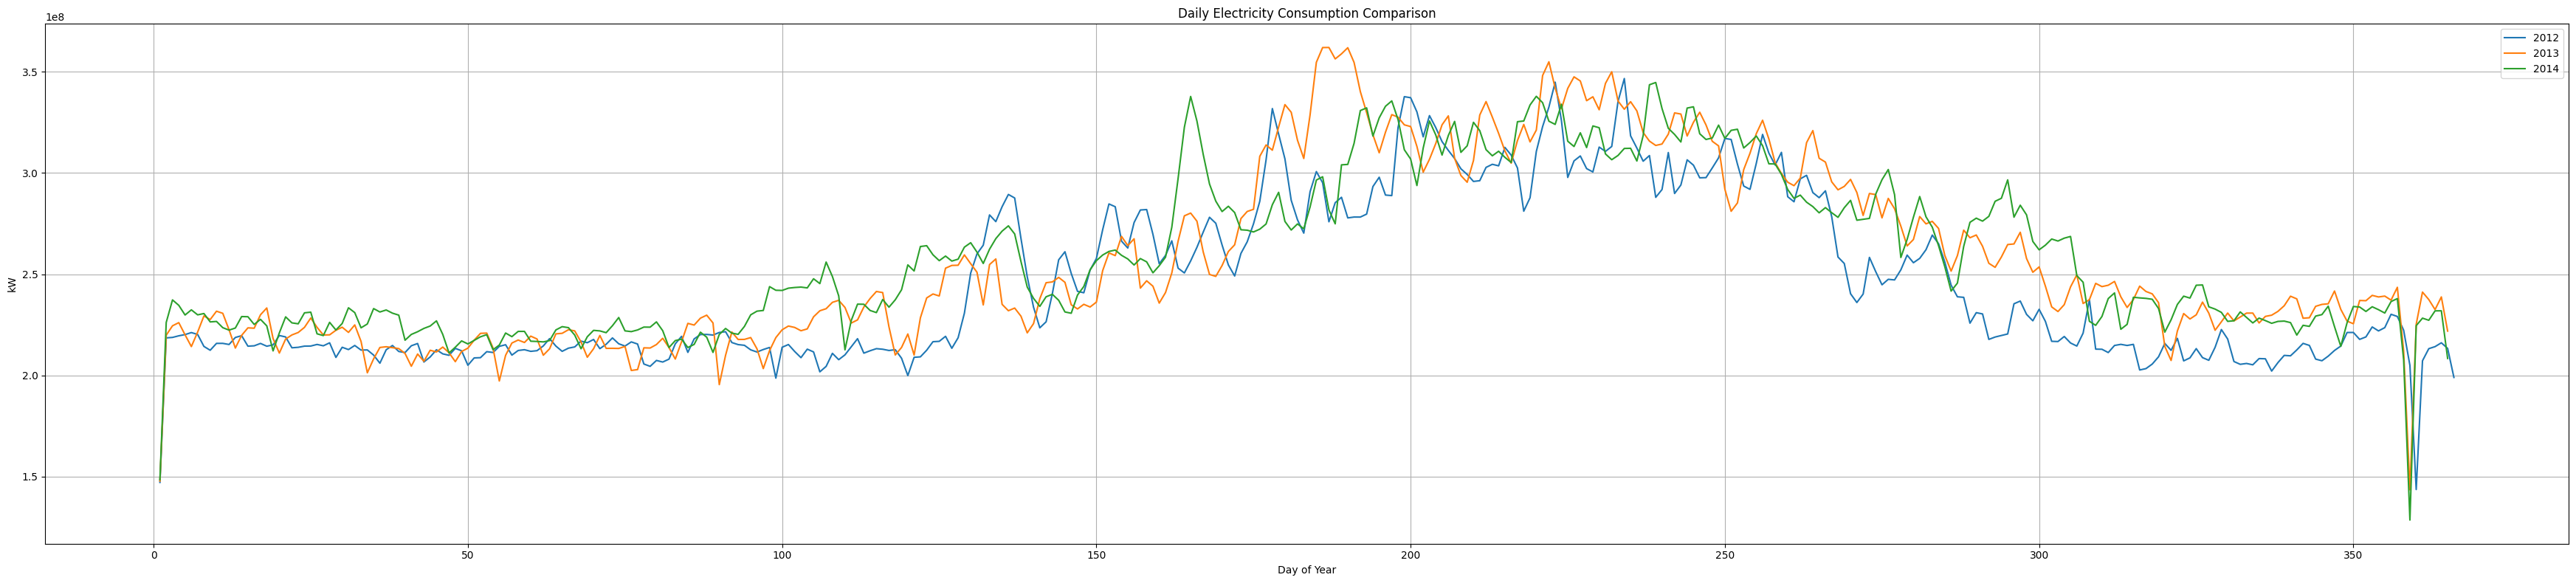

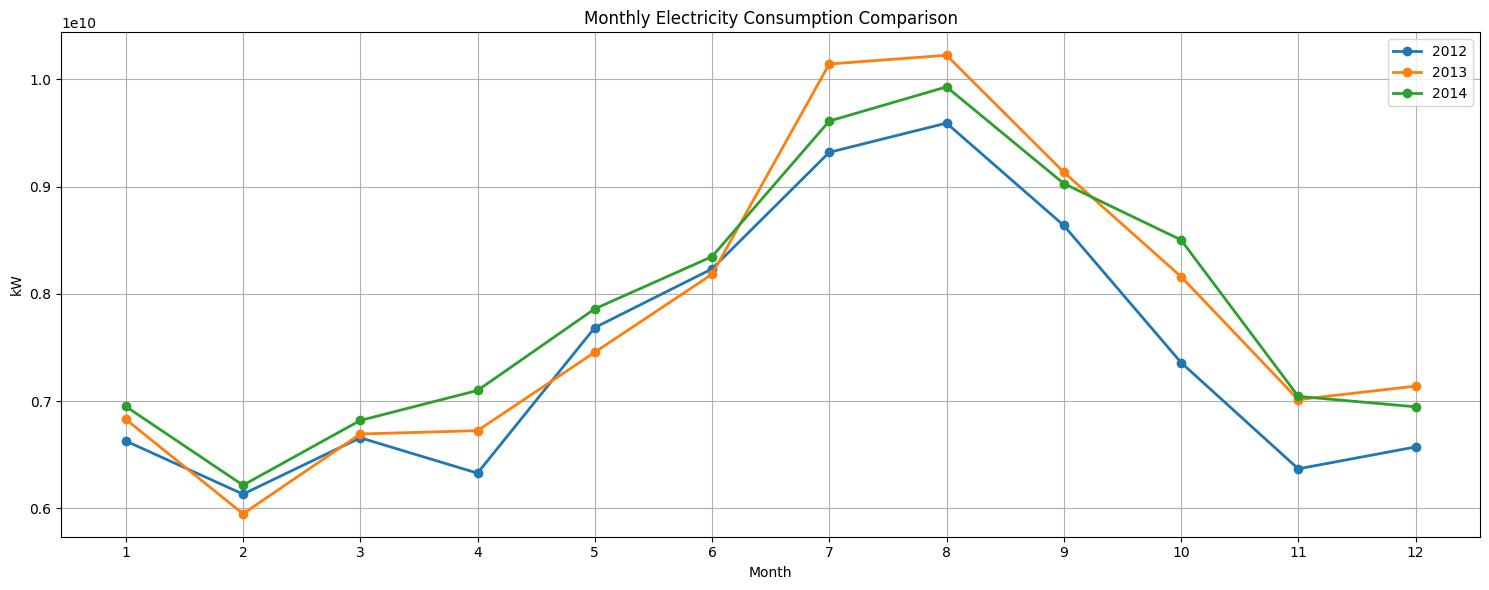

In [38]:
import matplotlib.pyplot as plt

# Tổng điện tiêu thụ
df["total_load"] = df.sum(axis=1)

years = [2012, 2013, 2014]

# =========================
# DAILY - 1 biểu đồ
# =========================
plt.figure(figsize=(35,8))

for year in years:

    year_df = df[df.index.year == year]

    # Gom theo ngày
    daily_df = year_df["total_load"].resample("D").sum()

    plt.plot(
        daily_df.index.dayofyear,   # để các năm chồng lên nhau
        daily_df.values,
        linewidth=1.5,
        label=str(year)
    )

plt.title("Daily Electricity Consumption Comparison")
plt.xlabel("Day of Year")
plt.ylabel("kW")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# =========================
# MONTHLY - 1 biểu đồ
# =========================
plt.figure(figsize=(15,6))

for year in years:

    year_df = df[df.index.year == year]

    # Gom theo tháng
    monthly_df = year_df["total_load"].resample("M").sum()

    plt.plot(
        monthly_df.index.month,
        monthly_df.values,
        marker='o',
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Electricity Consumption Comparison")
plt.xlabel("Month")
plt.ylabel("kW")
plt.xticks(range(1,13))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\YOGA\AppData\Local\Temp\ipykernel_3160\908058994.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_load"] = df.sum(axis=1)


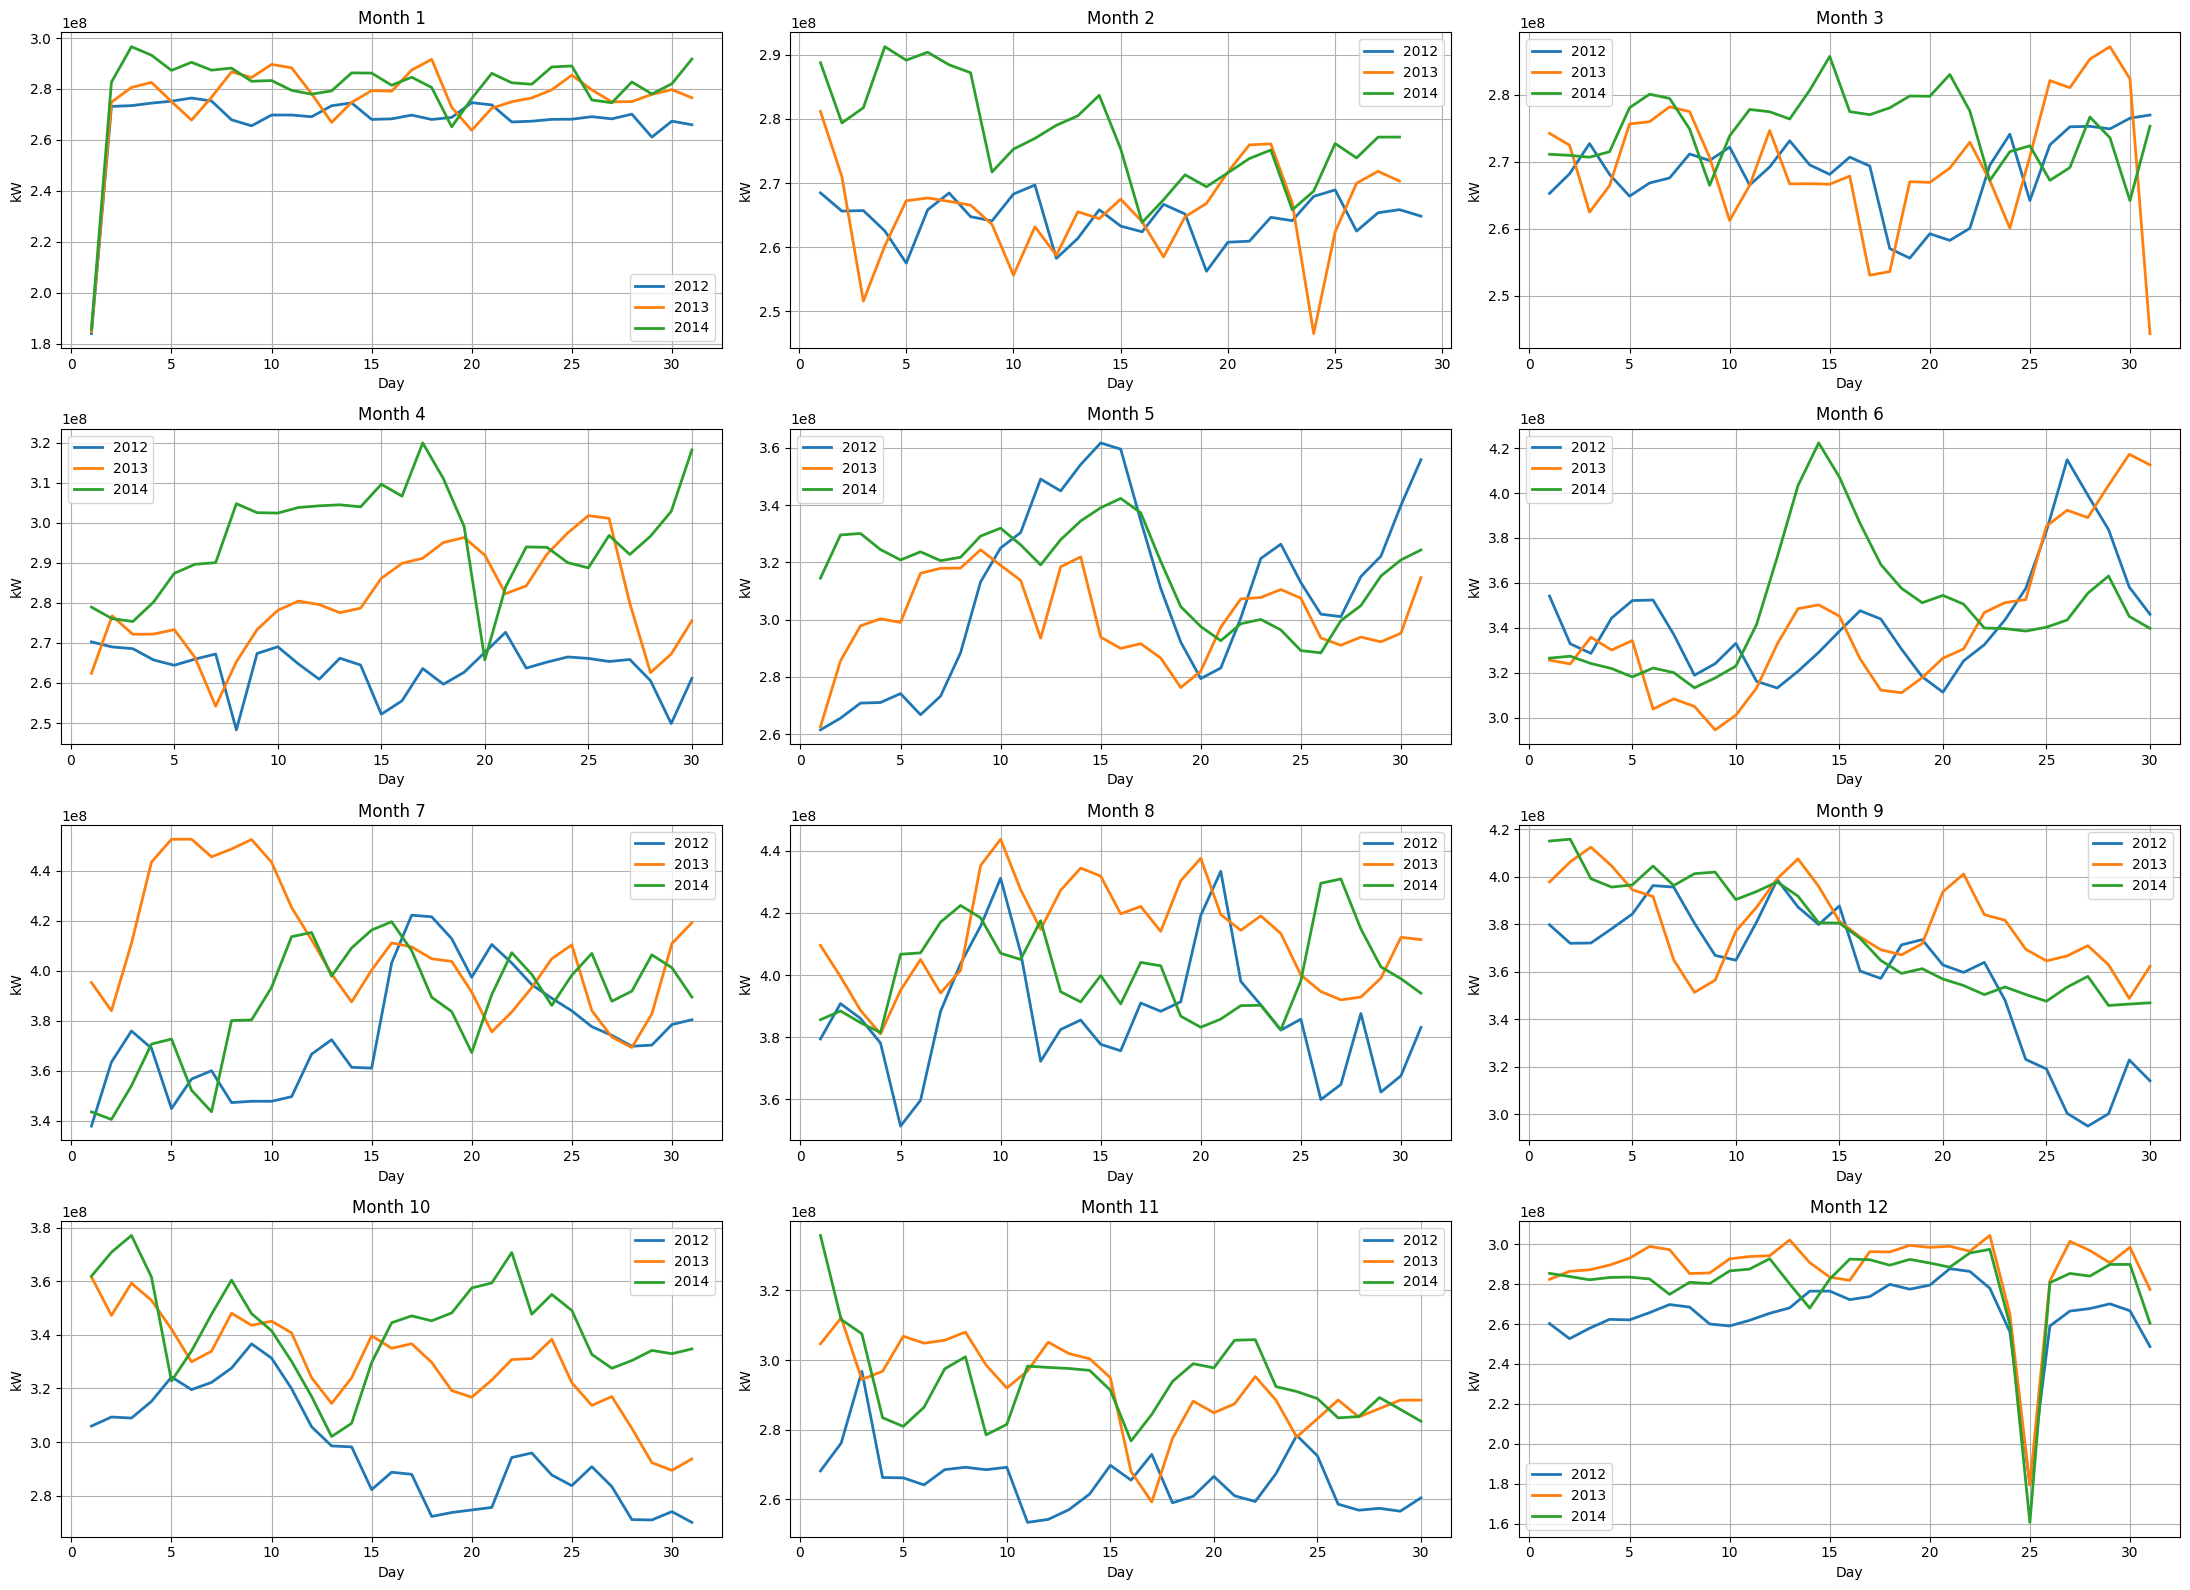

In [41]:
import matplotlib.pyplot as plt

# Tổng điện tiêu thụ
df["total_load"] = df.sum(axis=1)

years = [2012, 2013, 2014]

# Tạo 12 subplot
fig, axes = plt.subplots(4, 3, figsize=(22,16))

axes = axes.flatten()

for month in range(1, 13):

    for year in years:

        # Lọc theo năm và tháng
        month_df = df[
            (df.index.year == year) &
            (df.index.month == month)
        ]

        # Gom theo ngày
        daily_df = month_df["total_load"].resample("D").sum()

        # Vẽ
        axes[month-1].plot(
            daily_df.index.day,
            daily_df.values,
            linewidth=2,
            label=str(year)
        )

    axes[month-1].set_title(f"Month {month}")
    axes[month-1].set_xlabel("Day")
    axes[month-1].set_ylabel("kW")
    axes[month-1].grid(True)
    axes[month-1].legend()

plt.tight_layout()
plt.show()

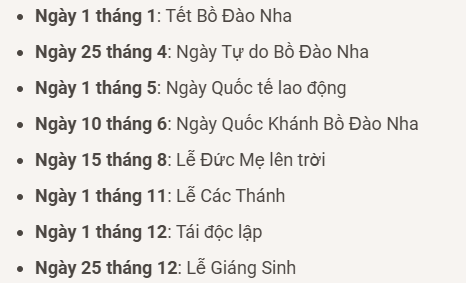

C:\Users\YOGA\AppData\Local\Temp\ipykernel_3160\2312441162.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_load"] = df.sum(axis=1)


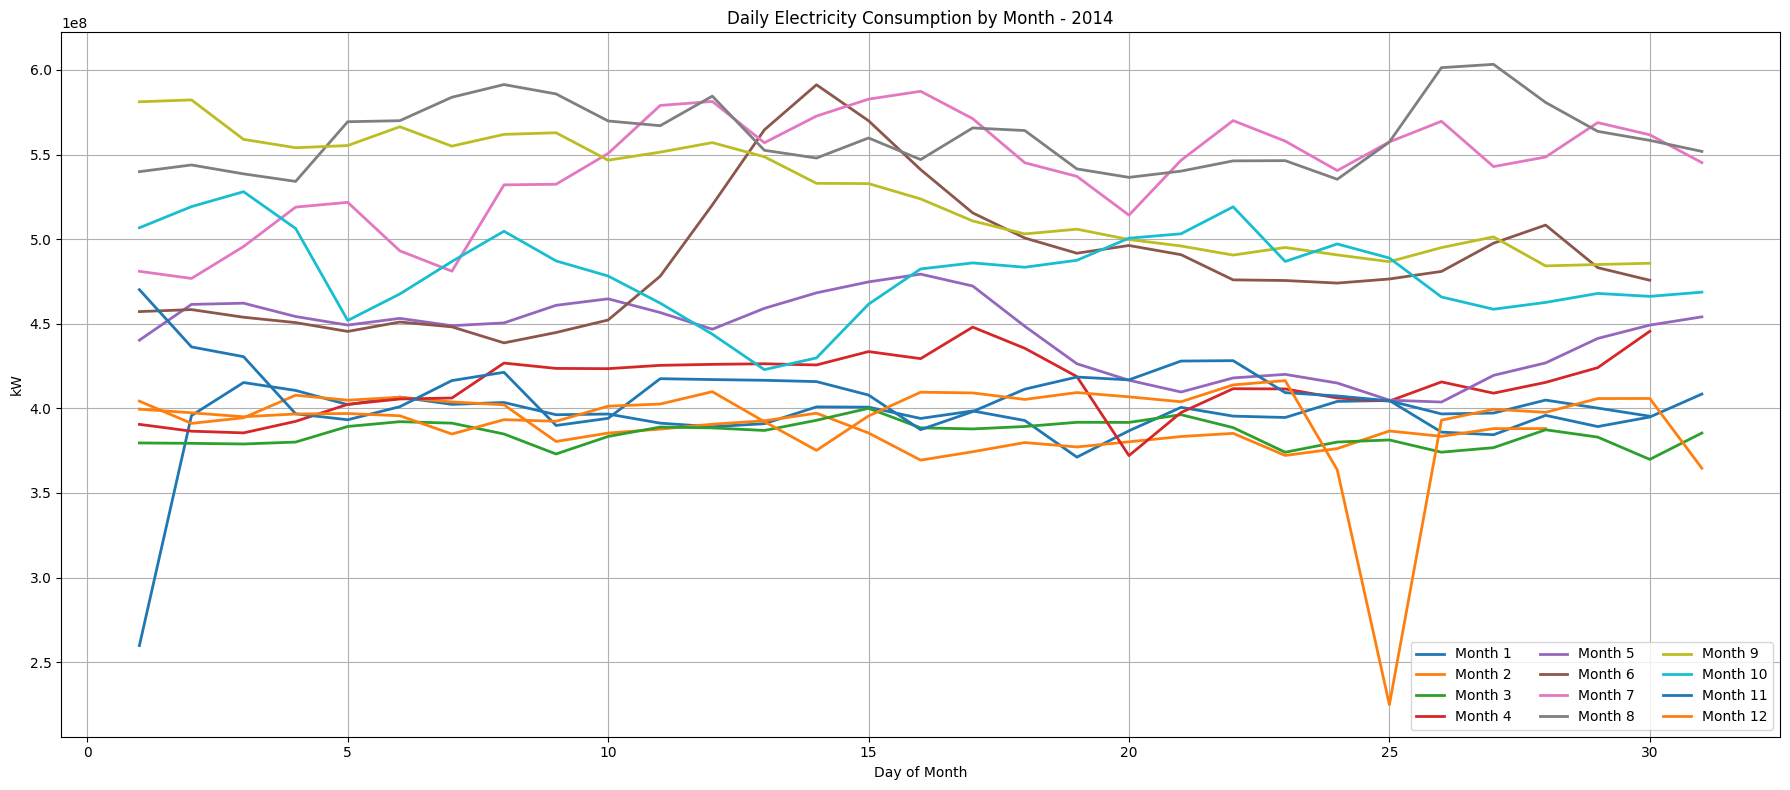

In [47]:
# Tổng điện tiêu thụ
df["total_load"] = df.sum(axis=1)

# Chọn năm
year = 2014

# Lọc dữ liệu năm
year_df = df[df.index.year == year]

# Tạo biểu đồ
plt.figure(figsize=(18,8))

for month in range(1, 13):

    # Lọc từng tháng
    month_df = year_df[year_df.index.month == month]

    # Gom theo ngày
    daily_df = month_df["total_load"].resample("D").sum()

    # Vẽ từng tháng
    plt.plot(
        daily_df.index.day,
        daily_df.values,
        linewidth=2,
        label=f"Month {month}"
    )

plt.title(f"Daily Electricity Consumption by Month - {year}")
plt.xlabel("Day of Month")
plt.ylabel("kW")

plt.legend(ncol=3)
plt.grid(True)

plt.tight_layout()
plt.show()

# Tuần

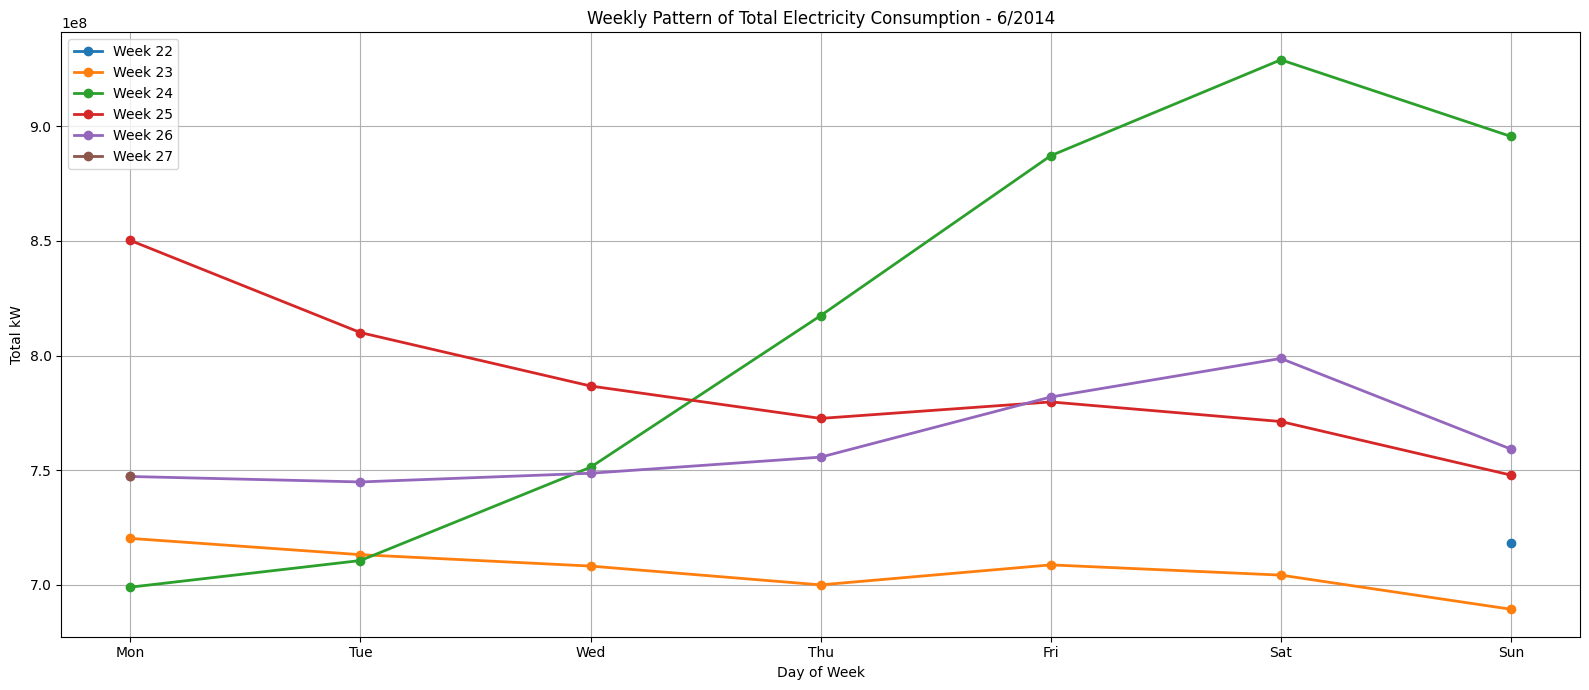

In [110]:
import matplotlib.pyplot as plt

# =========================
# TỔNG ĐIỆN TIÊU THỤ TOÀN BỘ KHÁCH HÀNG
# =========================
df["total_load"] = df.sum(axis=1)

# =========================
# LỌC NĂM 2014
# =========================
df_2014 = df[df.index.year == 2014].copy()

# =========================
# CHỌN THÁNG
# =========================
month = 6

month_df = df_2014[df_2014.index.month == month].copy()

# =========================
# GOM THEO NGÀY
# =========================
daily_df = month_df["total_load"].resample("D").sum().to_frame()

# ISO calendar (chuẩn châu Âu / Bồ Đào Nha)
iso = daily_df.index.isocalendar()

daily_df["week"] = iso.week
daily_df["weekday"] = iso.day

# =========================
# VẼ TỪNG TUẦN TRONG THÁNG
# =========================
plt.figure(figsize=(16,7))

for week in sorted(daily_df["week"].unique()):

    week_data = daily_df[daily_df["week"] == week]

    plt.plot(
        week_data["weekday"],
        week_data["total_load"],
        marker='o',
        linewidth=2,
        label=f"Week {week}"
    )

plt.title(f"Weekly Pattern of Total Electricity Consumption - {month}/2014")
plt.xlabel("Day of Week")
plt.ylabel("Total kW")

plt.xticks(
    [1,2,3,4,5,6,7],
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

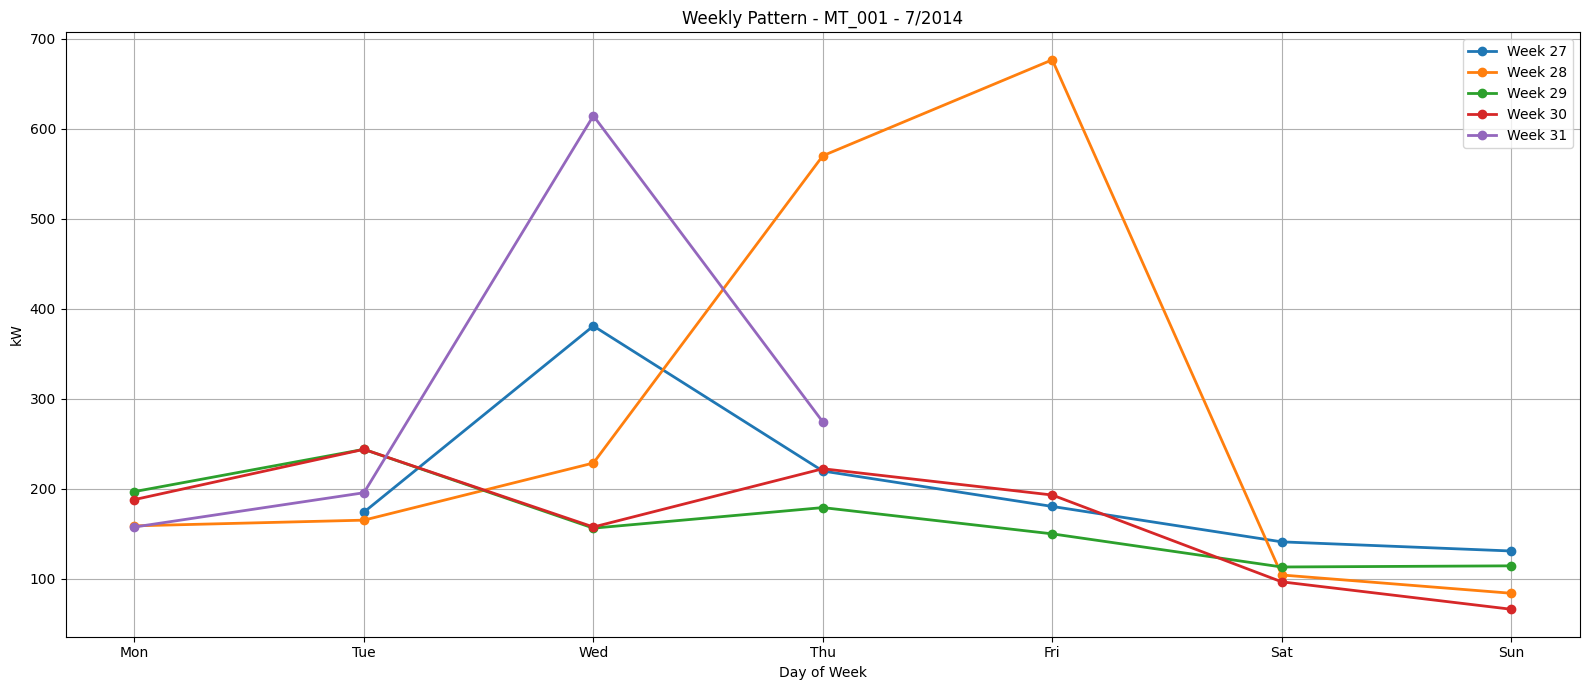

In [ ]:
import matplotlib.pyplot as plt

# =========================
# CHỌN KHÁCH HÀNG
# =========================
customer = df.columns[0]   # hoặc thay bằng tên cột cụ thể

# =========================
# LỌC NĂM 2014
# =========================
df_2014 = df[df.index.year == 2014].copy()

# =========================
# CHỌN THÁNG
# =========================
month = 7

month_df = df_2014[df_2014.index.month == month].copy()

# =========================
# GOM THEO NGÀY
# =========================
daily_df = month_df[customer].resample("D").sum().to_frame()

# ISO calendar
iso = daily_df.index.isocalendar()

daily_df["week"] = iso.week
daily_df["weekday"] = iso.day

# =========================
# VẼ TỪNG TUẦN TRONG THÁNG
# =========================
plt.figure(figsize=(16,7))

for week in sorted(daily_df["week"].unique()):

    week_data = daily_df[daily_df["week"] == week]

    plt.plot(
        week_data["weekday"],
        week_data[customer],
        marker='o',
        linewidth=2,
        label=f"Week {week}"
    )

plt.title(f"Weekly Pattern - {customer} - {month}/2014")
plt.xlabel("Day of Week")
plt.ylabel("kW")

plt.xticks(
    [1,2,3,4,5,6,7],
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

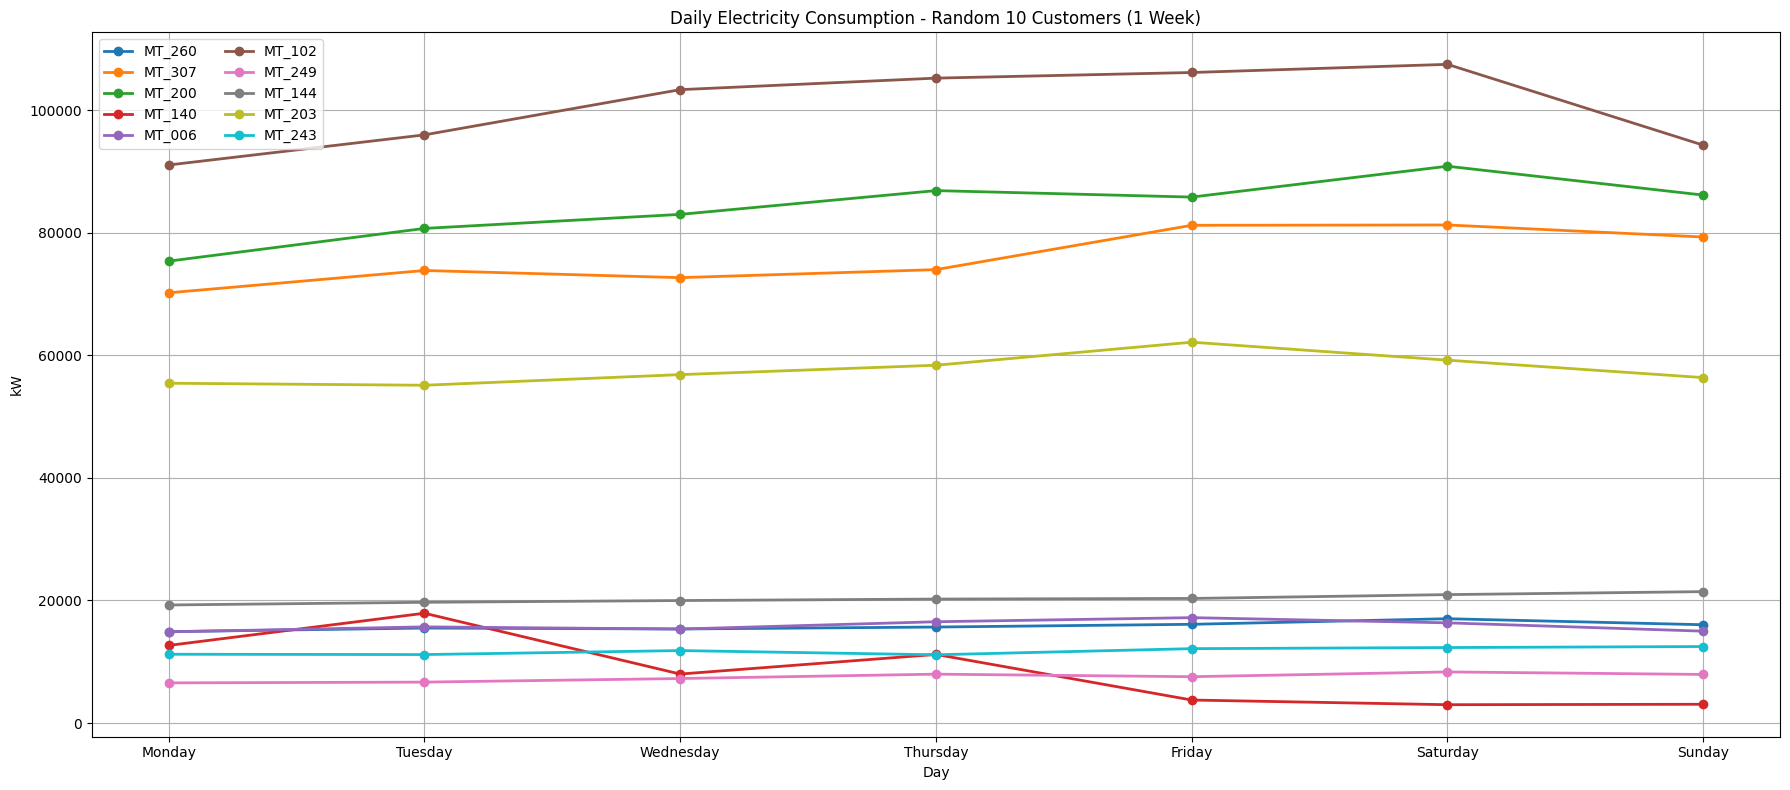

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# RANDOM 10 KHÁCH HÀNG
# =========================
customers = np.random.choice(df.columns, 10, replace=False)

# =========================
# LỌC 1 TUẦN CỤ THỂ
# =========================
week_df = df.loc["2014-07-07":"2014-07-13"].copy()

# =========================
# GOM THEO NGÀY
# =========================
daily_df = week_df[customers].resample("D").sum()

# =========================
# VẼ
# =========================
plt.figure(figsize=(18,8))

for customer in customers:

    plt.plot(
        daily_df.index.day_name(),
        daily_df[customer],
        marker='o',
        linewidth=2,
        label=customer
    )

plt.title("Daily Electricity Consumption - Random 10 Customers (1 Week)")
plt.xlabel("Day")
plt.ylabel("kW")

plt.legend(ncol=2)
plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\YOGA\AppData\Local\Temp\ipykernel_3160\3640173606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_load"] = df.sum(axis=1)


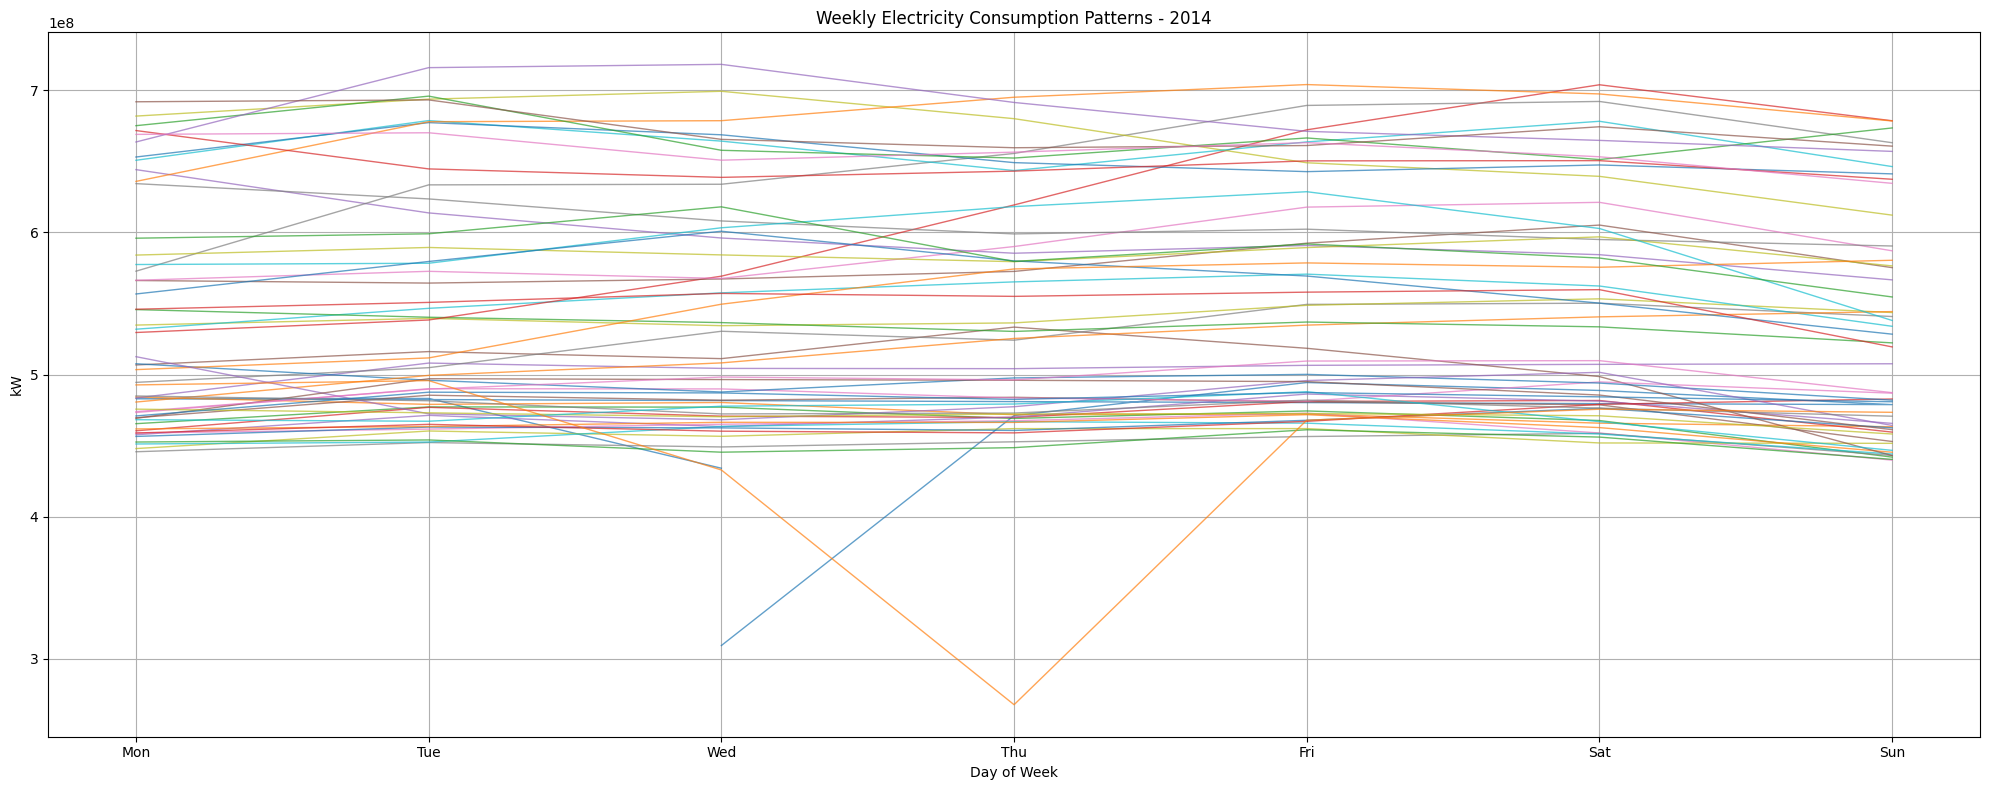

In [51]:
# Tổng điện tiêu thụ
df["total_load"] = df.sum(axis=1)

# Chọn năm
year = 2014

# Lọc dữ liệu năm
year_df = df[df.index.year == year].copy()

# Gom theo ngày
daily_df = year_df["total_load"].resample("D").sum().to_frame()

# ISO calendar (chuẩn Bồ Đào Nha / châu Âu)
iso_calendar = daily_df.index.isocalendar()

daily_df["week"] = iso_calendar.week
daily_df["weekday"] = iso_calendar.day

# Tạo biểu đồ
plt.figure(figsize=(20,8))

# Vẽ từng tuần
for week in sorted(daily_df["week"].unique()):

    week_data = daily_df[daily_df["week"] == week]

    plt.plot(
        week_data["weekday"],   # Thứ trong tuần
        week_data["total_load"],
        linewidth=1,
        alpha=0.7
    )

plt.title(f"Weekly Electricity Consumption Patterns - {year}")
plt.xlabel("Day of Week")
plt.ylabel("kW")

# Tên thứ theo chuẩn châu Âu
plt.xticks(
    [1,2,3,4,5,6,7],
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\YOGA\AppData\Local\Temp\ipykernel_3160\409773783.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_load"] = df.sum(axis=1)


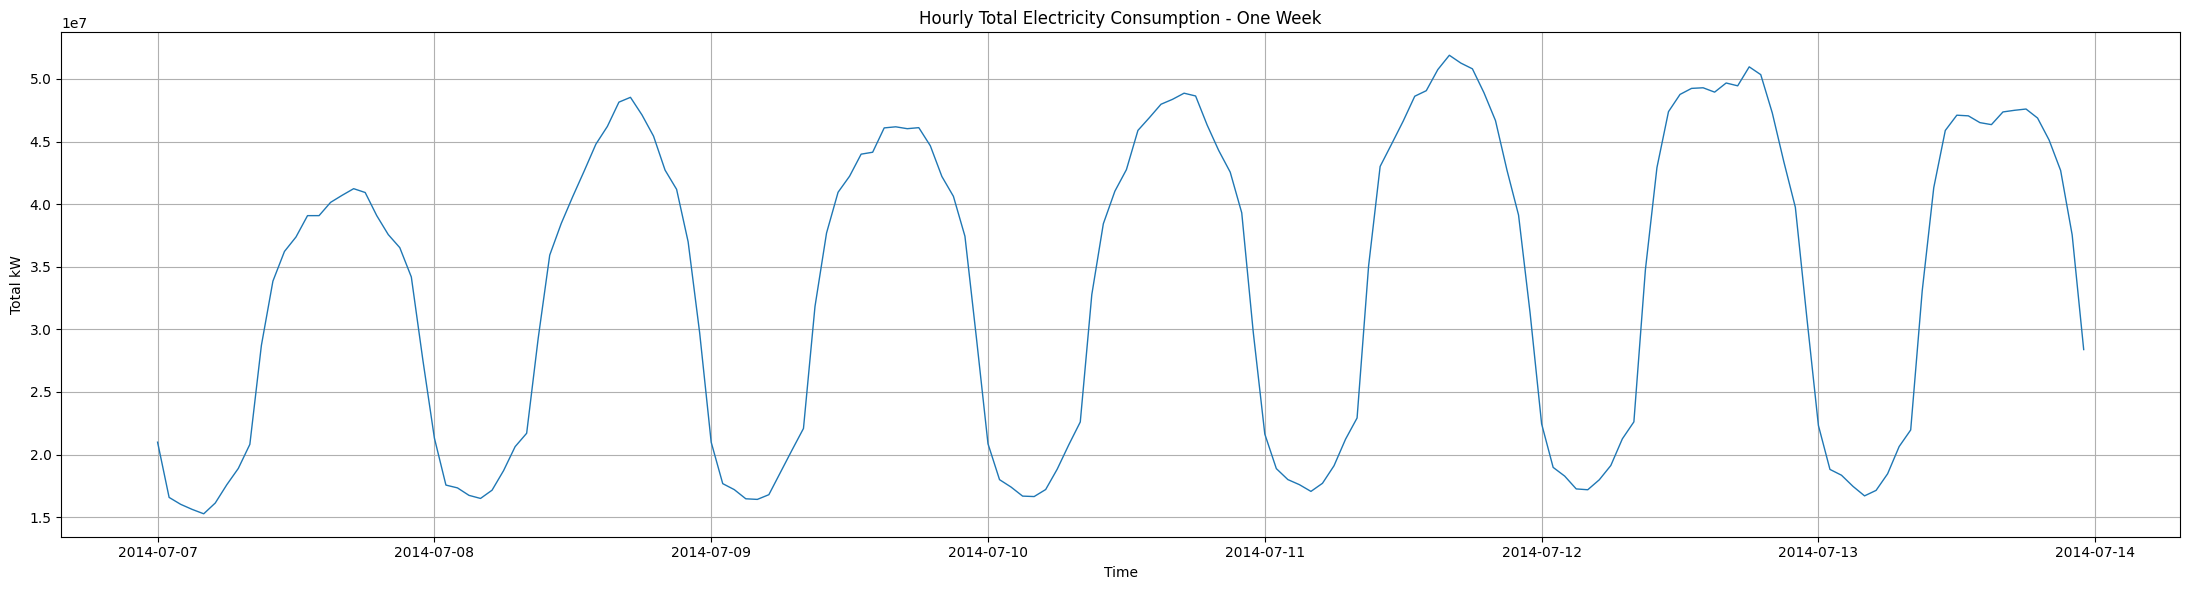

In [69]:
import matplotlib.pyplot as plt

# =========================
# TỔNG ĐIỆN TIÊU THỤ
# =========================
df["total_load"] = df.sum(axis=1)

# =========================
# CHỌN 1 TUẦN
# =========================
week_df = df.loc["2014-07-07":"2014-07-13"].copy()

# =========================
# GOM THEO GIỜ
# =========================
hourly_df = week_df["total_load"].resample("H").sum()

# =========================
# VẼ BIỂU ĐỒ
# =========================
plt.figure(figsize=(22,6))

plt.plot(
    hourly_df.index,
    hourly_df.values,
    linewidth=1
)

plt.title("Hourly Total Electricity Consumption - One Week")
plt.xlabel("Time")
plt.ylabel("Total kW")

plt.grid(True)

plt.tight_layout()
plt.show()

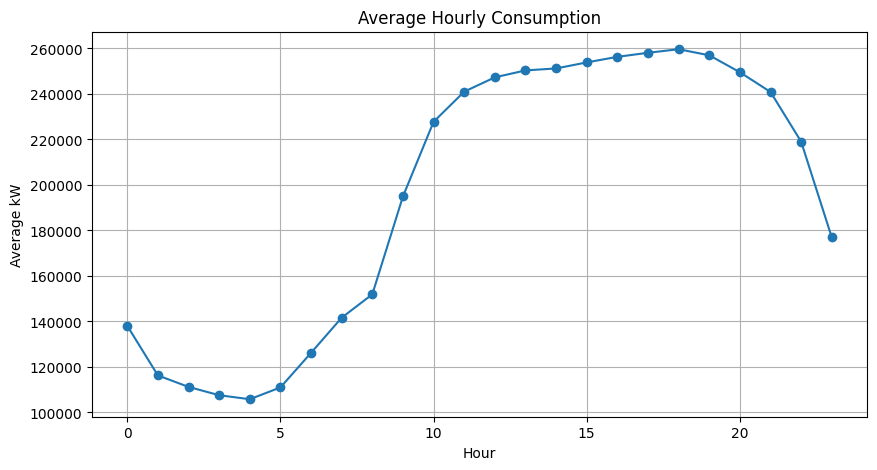

In [18]:
hourly_pattern = df.groupby(df.index.hour)["total_load"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title("Average Hourly Consumption")
plt.xlabel("Hour")
plt.ylabel("Average kW")
plt.grid(True)
plt.show()

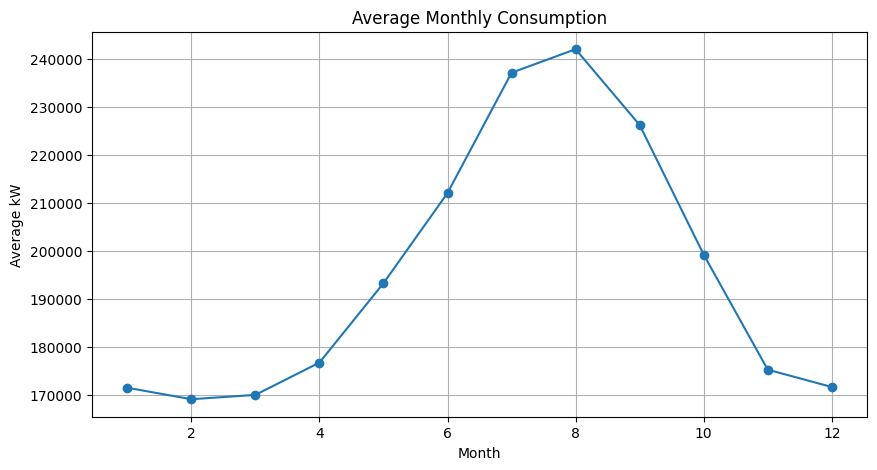

In [19]:
monthly_pattern = df.groupby(df.index.month)["total_load"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker='o')
plt.title("Average Monthly Consumption")
plt.xlabel("Month")
plt.ylabel("Average kW")
plt.grid(True)
plt.show()

# Giá trị 0

In [80]:
import matplotlib.pyplot as plt

# Chuyển thành binary:
# 1 = zero
# 0 = non-zero
zero_matrix = (df == 0).astype(int)

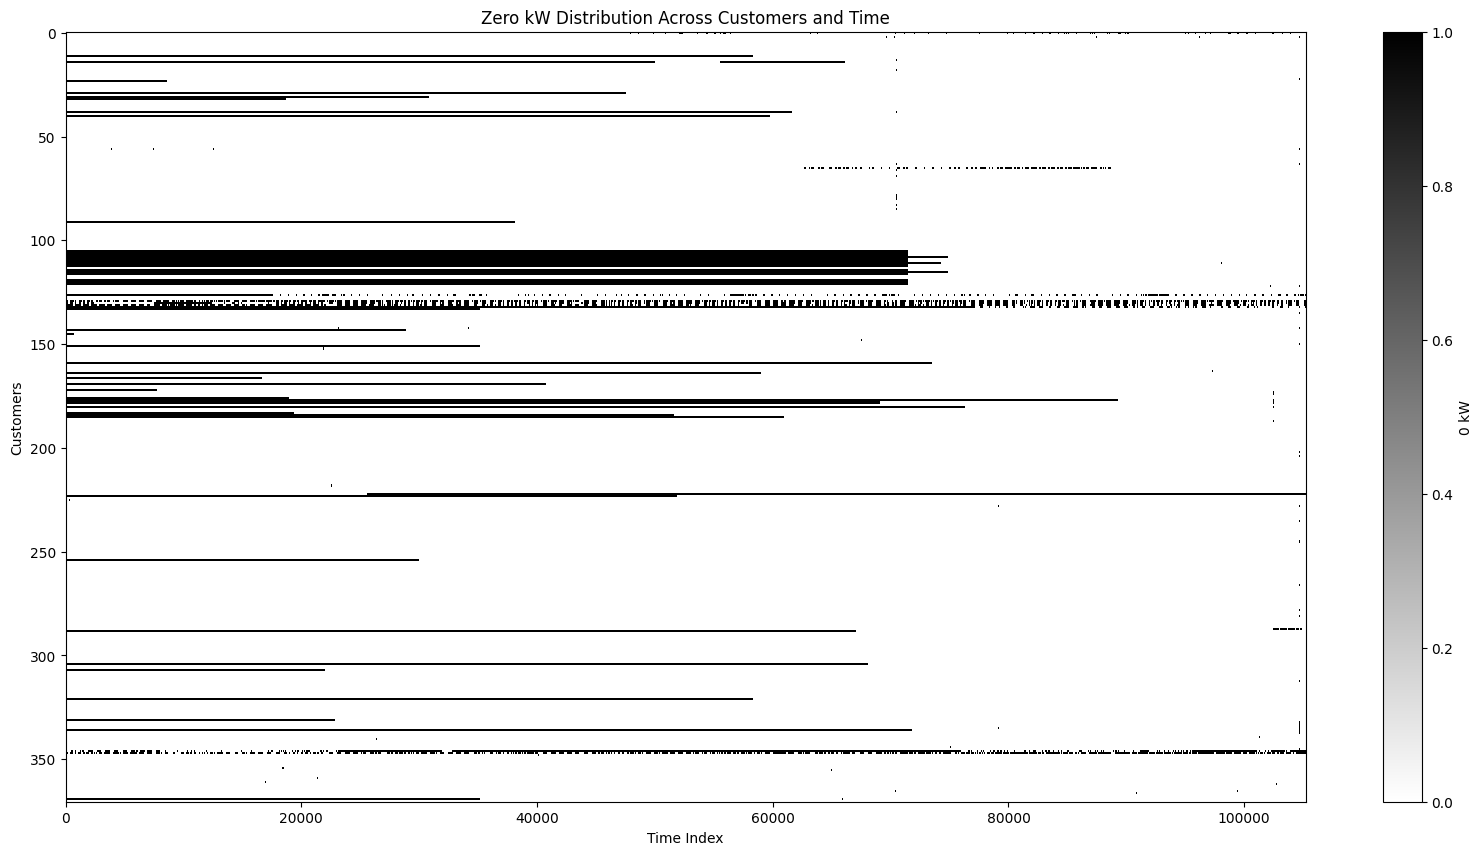

In [81]:
plt.figure(figsize=(20,10))

plt.imshow(
    zero_matrix.T,
    aspect='auto',
    cmap='binary',
    interpolation='nearest'
)

plt.title("Zero kW Distribution Across Customers and Time")
plt.xlabel("Time Index")
plt.ylabel("Customers")

plt.colorbar(label="0 kW")

plt.show()

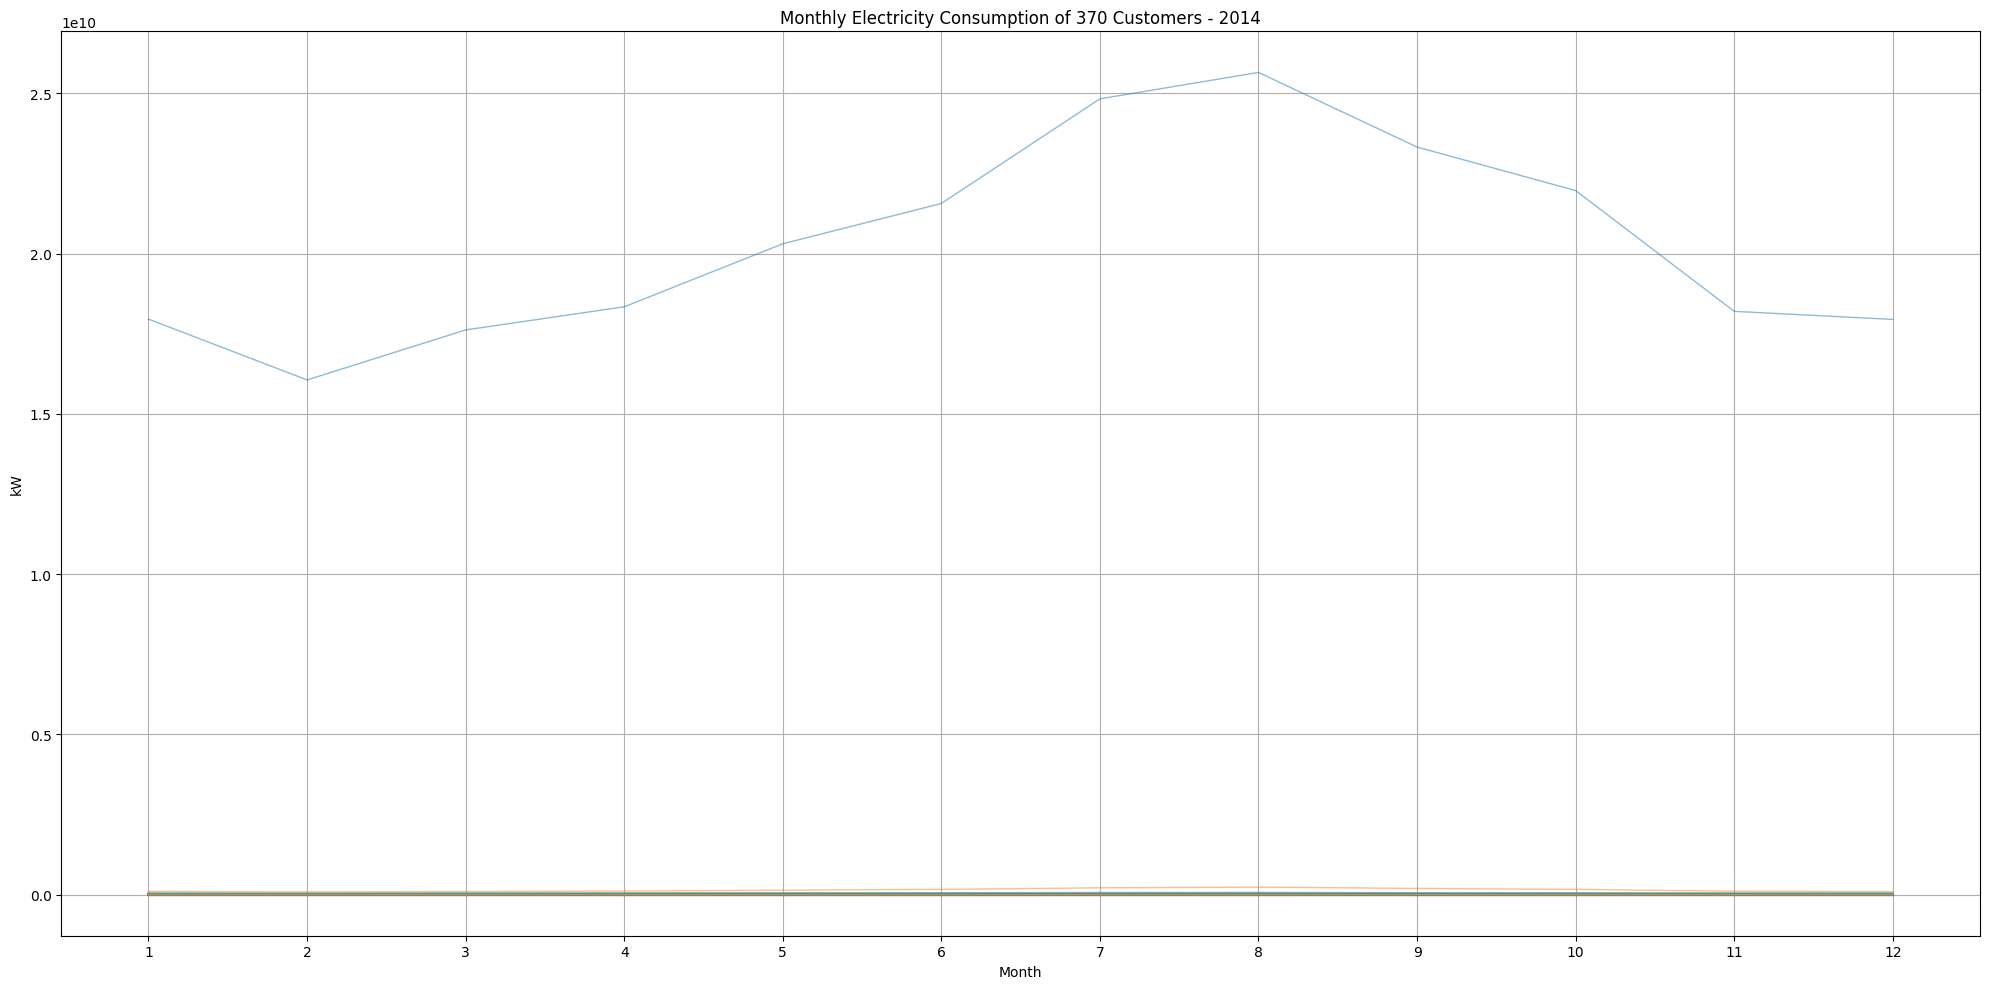

In [88]:
import matplotlib.pyplot as plt

# =========================
# LỌC NĂM 2014
# =========================
df_2014 = df[df.index.year == 2014]

# =========================
# GOM THEO THÁNG
# =========================
monthly_df = df_2014.resample("M").sum()

# =========================
# VẼ 370 KHÁCH HÀNG
# =========================
plt.figure(figsize=(20,10))

for customer in monthly_df.columns:

    plt.plot(
        monthly_df.index.month,
        monthly_df[customer],
        linewidth=1,
        alpha=0.5
    )

plt.title("Monthly Electricity Consumption of 370 Customers - 2014")
plt.xlabel("Month")
plt.ylabel("kW")

plt.xticks(range(1,13))
plt.grid(True)

plt.tight_layout()
plt.show()

In [93]:
import pandas as pd

# =========================
# LOẠI total_load NẾU CÓ
# =========================
customer_df = df.drop(
    columns=["total_load"],
    errors="ignore"
)

# =========================
# CHỈ LẤY DỮ LIỆU 2012-2014
# =========================
customer_df = customer_df.loc["2012":"2014"]

# =========================
# GROUP THEO ISO WEEK
# =========================
weekly_groups = customer_df.groupby(
    [
        customer_df.index.isocalendar().year,
        customer_df.index.isocalendar().week
    ]
)

best_week = None
min_zero_count = float("inf")

# =========================
# TÌM TUẦN ÍT ZERO NHẤT
# =========================
for (year, week), week_df in weekly_groups:

    # bỏ tuần thiếu ngày
    if len(week_df) < 7 * 96:
        continue

    zero_count = (week_df == 0).sum().sum()

    if zero_count < min_zero_count:

        min_zero_count = zero_count
        best_week = (year, week)
        best_week_df = week_df.copy()

print("Best Week (fewest zeros)")
print("Year :", best_week[0])
print("Week :", best_week[1])
print("Zero Values :", min_zero_count)

# =========================
# RANKING KHÁCH HÀNG
# =========================
customer_ranking = (
    best_week_df.sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_ranking.columns = ["Customer", "Total_kW"]

customer_ranking["Rank"] = range(
    1,
    len(customer_ranking)+1
)

# =========================
# FORMAT HIỂN THỊ
# =========================
customer_ranking["Total_kW"] = (
    customer_ranking["Total_kW"]
    .round(2)
)

# =========================
# TOP 20
# =========================
print(customer_ranking.head(20).to_string(index=False))

Best Week (fewest zeros)
Year : 2014
Week : 48
Zero Values : 2643
Customer    Total_kW  Rank
  MT_362 22780000.00     1
  MT_370 11588756.76     2
  MT_196 11437500.00     3
  MT_279  7327436.67     4
  MT_208  3771504.20     5
  MT_228  3280263.16     6
  MT_364  2104250.00     7
  MT_224  2001584.35     8
  MT_157  1810933.72     9
  MT_220  1788569.62    10
  MT_339  1777074.80    11
  MT_147  1642419.51    12
  MT_241  1632814.81    13
  MT_163  1579829.49    14
  MT_363  1492873.42    15
  MT_194  1362809.32    16
  MT_345  1347096.62    17
  MT_216  1215581.40    18
  MT_357  1192098.48    19
  MT_191  1183366.91    20
